# Updated Pipeline Assembly

> Updated Disaggregation and Aggregation

## Imports + Setup

In [1]:
## So that if you change sth in a src script you don't have to restart the kernel
%load_ext autoreload
%autoreload 2

In [2]:
## Imports
## Allowing for Imports from src folder
import sys
sys.path.append("..") # Adds the project root to the path

## Hazard + Exposure Import

In [ ]:
## Getting hazard Dict
from src.data_hazard import get_haz_dict

## TODO: Enable Floods!
haz_dict = get_haz_dict()

haz_dict

{'TC': {'hazard': <climada.hazard.base.Hazard at 0x327fc0e90>,
  'impf_set': <climada.entity.impact_funcs.impact_func_set.ImpactFuncSet at 0x330afe330>},
 'TP': {'hazard': <climada.hazard.base.Hazard at 0x324887fb0>,
  'impf_set': <climada.entity.impact_funcs.impact_func_set.ImpactFuncSet at 0x330b29340>},
 'HL': {'hazard': <climada.hazard.base.Hazard at 0x3268749e0>,
  'impf_set': <climada.entity.impact_funcs.impact_func_set.ImpactFuncSet at 0x32492c380>}}

In [4]:
from src.data_exposure import get_exposure

hazard_types = list(haz_dict.keys())

exposure_poly = get_exposure(hazard_types=hazard_types)

exposure_poly_gdf = exposure_poly.gdf

exposure_poly_gdf.head()

,DDEP_C_COD,DDEP_L_LIB,DREG_L_LIB,value,area,insurance,impf_TC,impf_TP,impf_HL,geometry
0,01,Ain,Auvergne-Rhône-Alpes,0.199,5762.4,0.30,1,1,1,"POLYGON ((6.16845 46.36746, 6.16668 46.37074, ..."
1,02,Aisne,Hauts-de-France,0.532,7361.7,0.32,1,1,1,"POLYGON ((4.25573 49.90398, 4.23694 49.90378, ..."
2,03,Allier,Auvergne-Rhône-Alpes,0.170,7340.1,0.30,1,1,1,"POLYGON ((4.00456 46.32748, 3.99436 46.32765, ..."
3,04,Alpes-de-Haute-Provence,Provence-Alpes-Côte d'Azur,0.025,6925.2,0.18,1,1,1,"POLYGON ((6.96709 44.62287, 6.9539 44.63783, 6..."
4,05,Hautes-Alpes,Provence-Alpes-Côte d'Azur,0.017,5548.7,0.18,1,1,1,"POLYGON ((7.07587 44.68512, 7.07424 44.69209, ..."


In [5]:
import climada.util.lines_polys_handler as u_lp

# TODO: Adjust Resolution
exposure_pnt = u_lp.exp_geom_to_pnt(
    exposure_poly,
    res=0.05,
    to_meters=False,
    disagg_met=u_lp.DisaggMethod.FIX,
    disagg_val=1,
)

exposure_pnt_gdf = exposure_pnt.gdf

## Compute Impact

In [6]:
from src.helpers import comp_impact

exposure_pnt_gdf["eai"] = comp_impact(
    haz_dict=haz_dict,
    exposure_pnt_gdf=exposure_pnt_gdf
)

2026-04-24 12:00:26,548 - climada.util.coordinates - WARNING - Distance to closest centroid is greater than 0.000237 degree for 25727 coordinates.


In [26]:
from src.helpers import comp_insurance

exposure_pnt_gdf["insurance"] = comp_insurance(
    method="eai",
    scaling_factor=0.5,
    insurance_current=exposure_pnt_gdf["insurance"],
    eai=exposure_pnt_gdf["eai"]
)

In [36]:

exposure_pnt_gdf

DDEP_C_COD  DDEP_L_LIB            DREG_L_LIB  value    area  insurance  \
0  0          01         Ain  Auvergne-Rhône-Alpes      1  5762.4   0.300000   
   1          01         Ain  Auvergne-Rhône-Alpes      1  5762.4   0.300000   
   2          01         Ain  Auvergne-Rhône-Alpes      1  5762.4   0.328179   
   3          01         Ain  Auvergne-Rhône-Alpes      1  5762.4   0.300000   
   4          01         Ain  Auvergne-Rhône-Alpes      1  5762.4   0.300000   
...          ...         ...                   ...    ...     ...        ...   
95 54         95  Val-d'Oise         Île-de-France      1  1245.9   0.731229   
   55         95  Val-d'Oise         Île-de-France      1  1245.9   0.731550   
   56         95  Val-d'Oise         Île-de-France      1  1245.9   0.731550   
   57         95  Val-d'Oise         Île-de-France      1  1245.9   0.731550   
   58         95  Val-d'Oise         Île-de-France      1  1245.9   0.734948   

       impf_TC  impf_TP  impf_HL  \
0  0         1        1        1   
   1         1        1        1   
   2         1        1        1   
   3         1        1        1   
   4         1        1        1   
...        ...      ...      ...   
95 54        1        1        1   
   55        1        1        1   
   56        1        1        1   
   57        1        1        1   
   58        1        1        1   

                                           geometry_orig  \
0  0   POLYGON ((6.16845 46.36746, 6.16668 46.37074, ...   
   1   POLYGON ((6.16845 46.36746, 6.16668 46.37074, ...   
   2   POLYGON ((6.16845 46.36746, 6.16668 46.37074, ...   
   3   POLYGON ((6.16845 46.36746, 6.16668 46.37074, ...   
   4   POLYGON ((6.16845 46.36746, 6.16668 46.37074, ...   
...                                                  ...   
95 54  POLYGON ((2.59447 49.04714, 2.57243 49.05926, ...   
   55  POLYGON ((2.59447 49.04714, 2.57243 49.05926, ...   
   56  POLYGON ((2.59447 49.04714, 2.57243 49.05926, ...   
   57  POLYGON ((2.59447 49.04714, 2.57243 49.05926, ...   
   58  POLYGON ((2.59447 49.04714, 2.57243 49.05926, ...   

                       geometry       eai  
0  0   POINT (5.63058 45.66149)  0.000000  
   1   POINT (5.68058 45.66149)  0.000000  
   2   POINT (5.58058 45.71149)  0.010231  
   3   POINT (5.63058 45.71149)  0.000000  
   4   POINT (5.68058 45.71149)  0.000000  
...                         ...       ...  
95 54   POINT (2.1088 49.15868)  0.004077  
   55   POINT (2.1588 49.15868)  0.004194  
   56   POINT (2.2088 49.15868)  0.004194  
   57   POINT (2.3088 49.15868)  0.004194  
   58   POINT (1.7088 49.20868)  0.005427  

[25740 rows x 12 columns]

In [38]:
comp_who_pays(
        relative_damage=exposure_pnt_gdf["eai"],
        insured=exposure_pnt_gdf["insurance"]
    )

,F,I,G
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,1.0,0.0,0.0
...,...,...,...
25735,1.0,0.0,0.0
25736,1.0,0.0,0.0
25737,1.0,0.0,0.0
25738,1.0,0.0,0.0


In [39]:
exposure_pnt_gdf

DDEP_C_COD  DDEP_L_LIB            DREG_L_LIB  value    area  insurance  \
0  0          01         Ain  Auvergne-Rhône-Alpes      1  5762.4   0.300000   
   1          01         Ain  Auvergne-Rhône-Alpes      1  5762.4   0.300000   
   2          01         Ain  Auvergne-Rhône-Alpes      1  5762.4   0.328179   
   3          01         Ain  Auvergne-Rhône-Alpes      1  5762.4   0.300000   
   4          01         Ain  Auvergne-Rhône-Alpes      1  5762.4   0.300000   
...          ...         ...                   ...    ...     ...        ...   
95 54         95  Val-d'Oise         Île-de-France      1  1245.9   0.731229   
   55         95  Val-d'Oise         Île-de-France      1  1245.9   0.731550   
   56         95  Val-d'Oise         Île-de-France      1  1245.9   0.731550   
   57         95  Val-d'Oise         Île-de-France      1  1245.9   0.731550   
   58         95  Val-d'Oise         Île-de-France      1  1245.9   0.734948   

       impf_TC  impf_TP  impf_HL  \
0  0         1        1        1   
   1         1        1        1   
   2         1        1        1   
   3         1        1        1   
   4         1        1        1   
...        ...      ...      ...   
95 54        1        1        1   
   55        1        1        1   
   56        1        1        1   
   57        1        1        1   
   58        1        1        1   

                                           geometry_orig  \
0  0   POLYGON ((6.16845 46.36746, 6.16668 46.37074, ...   
   1   POLYGON ((6.16845 46.36746, 6.16668 46.37074, ...   
   2   POLYGON ((6.16845 46.36746, 6.16668 46.37074, ...   
   3   POLYGON ((6.16845 46.36746, 6.16668 46.37074, ...   
   4   POLYGON ((6.16845 46.36746, 6.16668 46.37074, ...   
...                                                  ...   
95 54  POLYGON ((2.59447 49.04714, 2.57243 49.05926, ...   
   55  POLYGON ((2.59447 49.04714, 2.57243 49.05926, ...   
   56  POLYGON ((2.59447 49.04714, 2.57243 49.05926, ...   
   57  POLYGON ((2.59447 49.04714, 2.57243 49.05926, ...   
   58  POLYGON ((2.59447 49.04714, 2.57243 49.05926, ...   

                       geometry       eai  
0  0   POINT (5.63058 45.66149)  0.000000  
   1   POINT (5.68058 45.66149)  0.000000  
   2   POINT (5.58058 45.71149)  0.010231  
   3   POINT (5.63058 45.71149)  0.000000  
   4   POINT (5.68058 45.71149)  0.000000  
...                         ...       ...  
95 54   POINT (2.1088 49.15868)  0.004077  
   55   POINT (2.1588 49.15868)  0.004194  
   56   POINT (2.2088 49.15868)  0.004194  
   57   POINT (2.3088 49.15868)  0.004194  
   58   POINT (1.7088 49.20868)  0.005427  

[25740 rows x 12 columns]

In [48]:
from src.helpers import comp_who_pays

result = comp_who_pays(
    relative_damage=exposure_pnt_gdf["eai"],
    insured=exposure_pnt_gdf["insurance"]
)

exposure_pnt_gdf[["F", "I", "G"]] = result[["F", "I", "G"]].to_numpy()

In [60]:
from src.helpers import agg_to_departement

results = agg_to_departement(
    pnt_gdf=exposure_pnt_gdf,
    value_cols=["insurance", "eai", "F", "I", "G"],
    agg_func="mean"
)

In [62]:
results

,DDEP_C_COD,DDEP_L_LIB,DREG_L_LIB,area,insurance,eai,F,I,G,geometry_orig
0,01,Ain,Auvergne-Rhône-Alpes,5762.4,0.349364,0.017923,1.000000,0.000000,0.000000,"POLYGON ((6.16845 46.36746, 6.16668 46.37074, ..."
1,02,Aisne,Hauts-de-France,7361.7,0.332501,0.004539,1.000000,0.000000,0.000000,"POLYGON ((4.25573 49.90398, 4.23694 49.90378, ..."
2,03,Allier,Auvergne-Rhône-Alpes,7340.1,0.386815,0.033125,0.997143,0.000286,0.002571,"POLYGON ((4.00456 46.32748, 3.99436 46.32765, ..."
3,04,Alpes-de-Haute-Provence,Provence-Alpes-Côte d'Azur,6925.2,0.180304,0.000110,1.000000,0.000000,0.000000,"POLYGON ((6.96709 44.62287, 6.9539 44.63783, 6..."
4,05,Hautes-Alpes,Provence-Alpes-Côte d'Azur,5548.7,0.183228,0.003717,0.996063,0.000394,0.003543,"POLYGON ((7.07587 44.68512, 7.07424 44.69209, ..."
...,...,...,...,...,...,...,...,...,...,...
91,91,Essonne,Île-de-France,1804.4,0.763824,0.015912,1.000000,0.000000,0.000000,"POLYGON ((2.58407 48.67715, 2.58038 48.68948, ..."
92,92,Hauts-de-Seine,Île-de-France,175.6,0.742037,0.008001,1.000000,0.000000,0.000000,"POLYGON ((2.33598 48.93158, 2.33491 48.94154, ..."
93,93,Seine-Saint-Denis,Île-de-France,236.2,0.745498,0.009258,1.000000,0.000000,0.000000,"POLYGON ((2.6026 48.92936, 2.6024 48.93532, 2...."
94,94,Val-de-Marne,Île-de-France,245.0,0.756975,0.013425,1.000000,0.000000,0.000000,"POLYGON ((2.61482 48.76112, 2.60645 48.77333, ..."


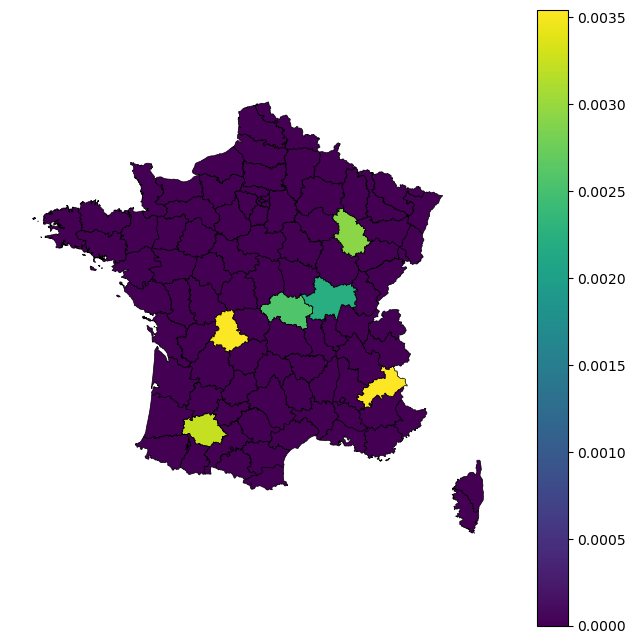

In [67]:
## Plotting Any Column
## Idea: Value (Exposure) x EAI = damaged_area

import geopandas as gpd
import matplotlib.pyplot as plt

# gdf is your GeoDataFrame
# columns: geometry (polygons), value (numeric or categorical)

fig, ax = plt.subplots(figsize=(8, 8))

results.plot(
    column="G",      # column used for coloring
    ax=ax,
    cmap="viridis",      # color map
    legend=True,         # show color bar / legend
    edgecolor="black",   # polygon borders
    linewidth=0.5
)

ax.set_axis_off()
plt.show()

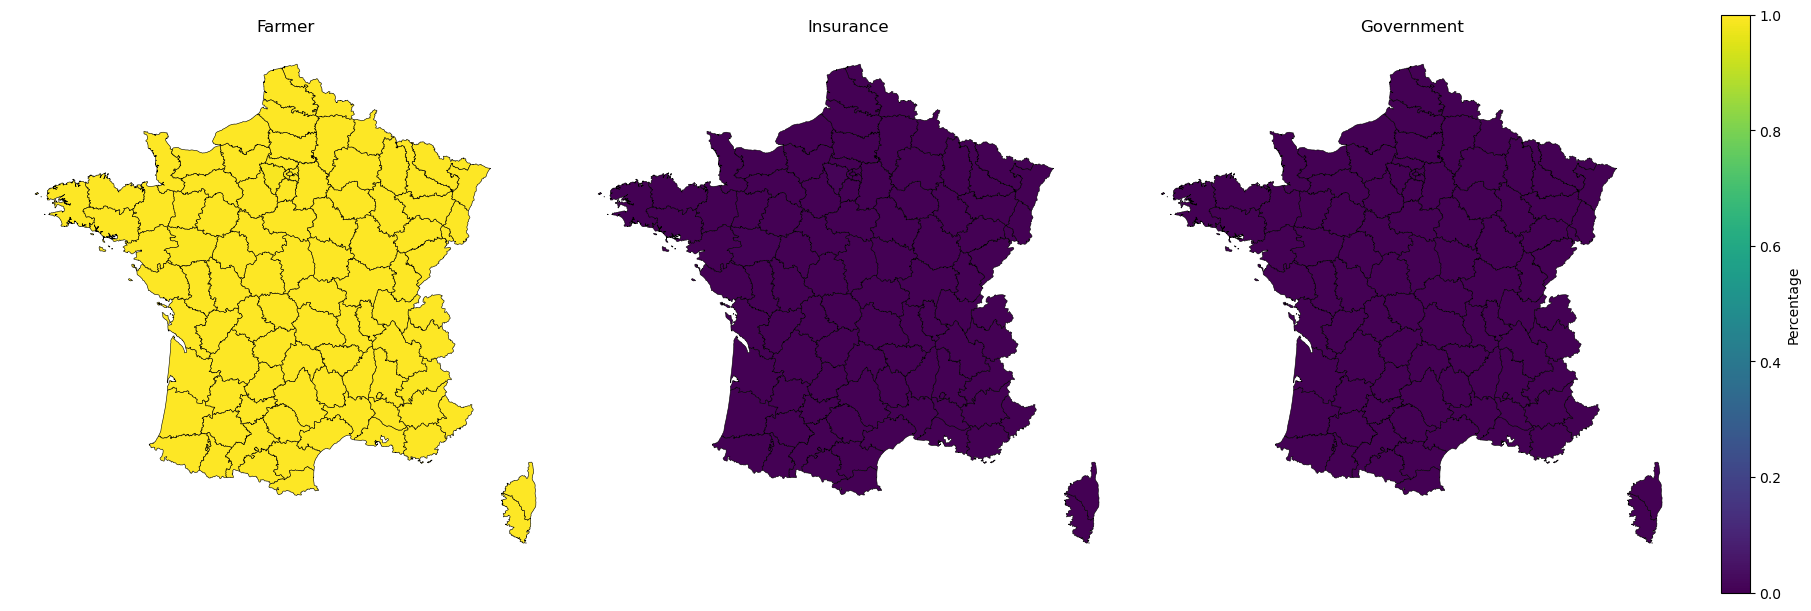

In [61]:
## Plotting
## Who Pays Damaged Area in Percent

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Columns to plot
cols = ["F", "I", "G"]
titles = ["Farmer", "Insurance", "Government"]

# Create figure and axes
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, 6),
    constrained_layout=True
)

# Shared color normalization (0–1 for percentages)
# Compute global min/max across all three columns
#vmin = df[cols].min().min()
#vmax = df[cols].max().max()
# norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# For Percentages
norm = mpl.colors.Normalize(vmin=0, vmax=1)

cmap = "viridis"

# Plot each column
for ax, col, title in zip(axes, cols, titles):
    results.plot(
        column=col,
        ax=ax,
        cmap=cmap,
        norm=norm,              # ensures shared scale
        edgecolor="black",
        linewidth=0.4
    )
    ax.set_title(title)
    ax.set_axis_off()

# Create a single colorbar
sm = mpl.cm.ScalarMappable(
    cmap=cmap,
    norm=norm
)
sm.set_array([])  # required for older matplotlib versions

cbar = fig.colorbar(
    sm,
    ax=axes,
    orientation="vertical",
    fraction=0.025,
    pad=0.02
)
cbar.set_label("Percentage")

plt.show()